# Task 3: Predictive modeling & time-Series forecasting

### I. Target variable isolation (Square 5161, 4159, 4556)
To begin the predictive modeling phase, the dataset must be filtered to isolate the specific geographical area of interest and based on the exploratory data analysis in task 2, square 5161 4159, 4556 was identified  exhibiting extreme variance and a rigid 24-hour seasonality. 

**Extraction Methodology:**
To adhere to the strict memory constraints established in Task 1, i processed the 5GB `milan_traffic_UltraClean.csv` file  using a chunked iteration, i then extracted the target time series, concatenated, and strictly sorted by the `TimeInterval` column.
 Sorting is a critical prerequisite for time-series forecasting to ensure absolute chronological integrity before the data is split into training and testing sets or fed into the autoregressive algorithms.

In [ ]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

tf.random.set_seed(42)
np.random.seed(42)

print("Loading all 3 areas from milan_traffic_UltraClean.csv...")
start_time = time.time()

chunk_size = 2000000
target_ids = [5161, 4159, 4556]
collected  = {sid: [] for sid in target_ids}

for chunk in pd.read_csv('milan_traffic_UltraClean.csv', chunksize=chunk_size):
    for sid in target_ids:
        filtered = chunk[chunk['SquareId'] == sid]
        if len(filtered) > 0:
            collected[sid].append(filtered)

# build one sorted series per area
area1_full_series = pd.concat(collected[5161]).sort_values('TimeInterval')['Internet'].values
area2_full_series = pd.concat(collected[4159]).sort_values('TimeInterval')['Internet'].values
area3_full_series = pd.concat(collected[4556]).sort_values('TimeInterval')['Internet'].values

print(f"Done in {time.time()-start_time:.1f}s")
print(f"Area 5161 (Highest): {len(area1_full_series):,} records")
print(f"Area 4159          : {len(area2_full_series):,} records")
print(f"Area 4556          : {len(area3_full_series):,} records")

AREA_NAMES = [
    'Square 5161 (Highest Traffic)',
    'Square ID 4159',
    'Square ID 4556'
]

area_data_list = [
    area1_full_series,
    area2_full_series,
    area3_full_series
]
#constants
TEST_SIZE  = 1008   
TRAIN_SIZE = 2016   
SEQ_LEN    = 288   

def split_data(full_series, train_size, test_size):
    data  = np.array(full_series).flatten()
    train = data[-(train_size + test_size):-test_size]
    test  = data[-test_size:]
    return train, test

def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual > 1.0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def calculate_smape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2
    mask = denominator > 0
    return np.mean(np.abs(actual[mask] - predicted[mask]) / denominator[mask]) * 100

def compute_metrics(actual, predicted):
    mae   = mean_absolute_error(actual, predicted)
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mape  = calculate_mape(actual, predicted)
    smape = calculate_smape(actual, predicted)
    return mae, rmse, mape, smape

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(X), np.array(y)

results = {
    'Holt-Winters': {},
    'LSTM': {},
    'GRU': {}
}

print("\nSetup complete.")
print(f"   Train size     : {TRAIN_SIZE} steps = {TRAIN_SIZE/144:.1f} days")
print(f"   Test size      : {TEST_SIZE}  steps = {TEST_SIZE/144:.1f} days")
print(f"   Sequence length: {SEQ_LEN}    steps = {SEQ_LEN/144:.1f} days")

Loading all 3 areas from milan_traffic_UltraClean.csv...
Done in 80.8s
Area 5161 (Highest): 73,632 records
Area 4159          : 22,907 records
Area 4556          : 23,493 records

Setup complete.
   Train size     : 2016 steps = 14.0 days
   Test size      : 1008  steps = 7.0 days
   Sequence length: 288    steps = 2.0 days


### II. Chronological Visual Validation
Before initializing the forecasting algorithms, i performed a visual validation of one of the the isolated time-series  to ensure data integrity.



Loading all 3 target areas...
Loading complete in 106.63 seconds!
  Square 5161: 73,632 records
  Square 4159: 22,907 records
  Square 4556: 23,493 records


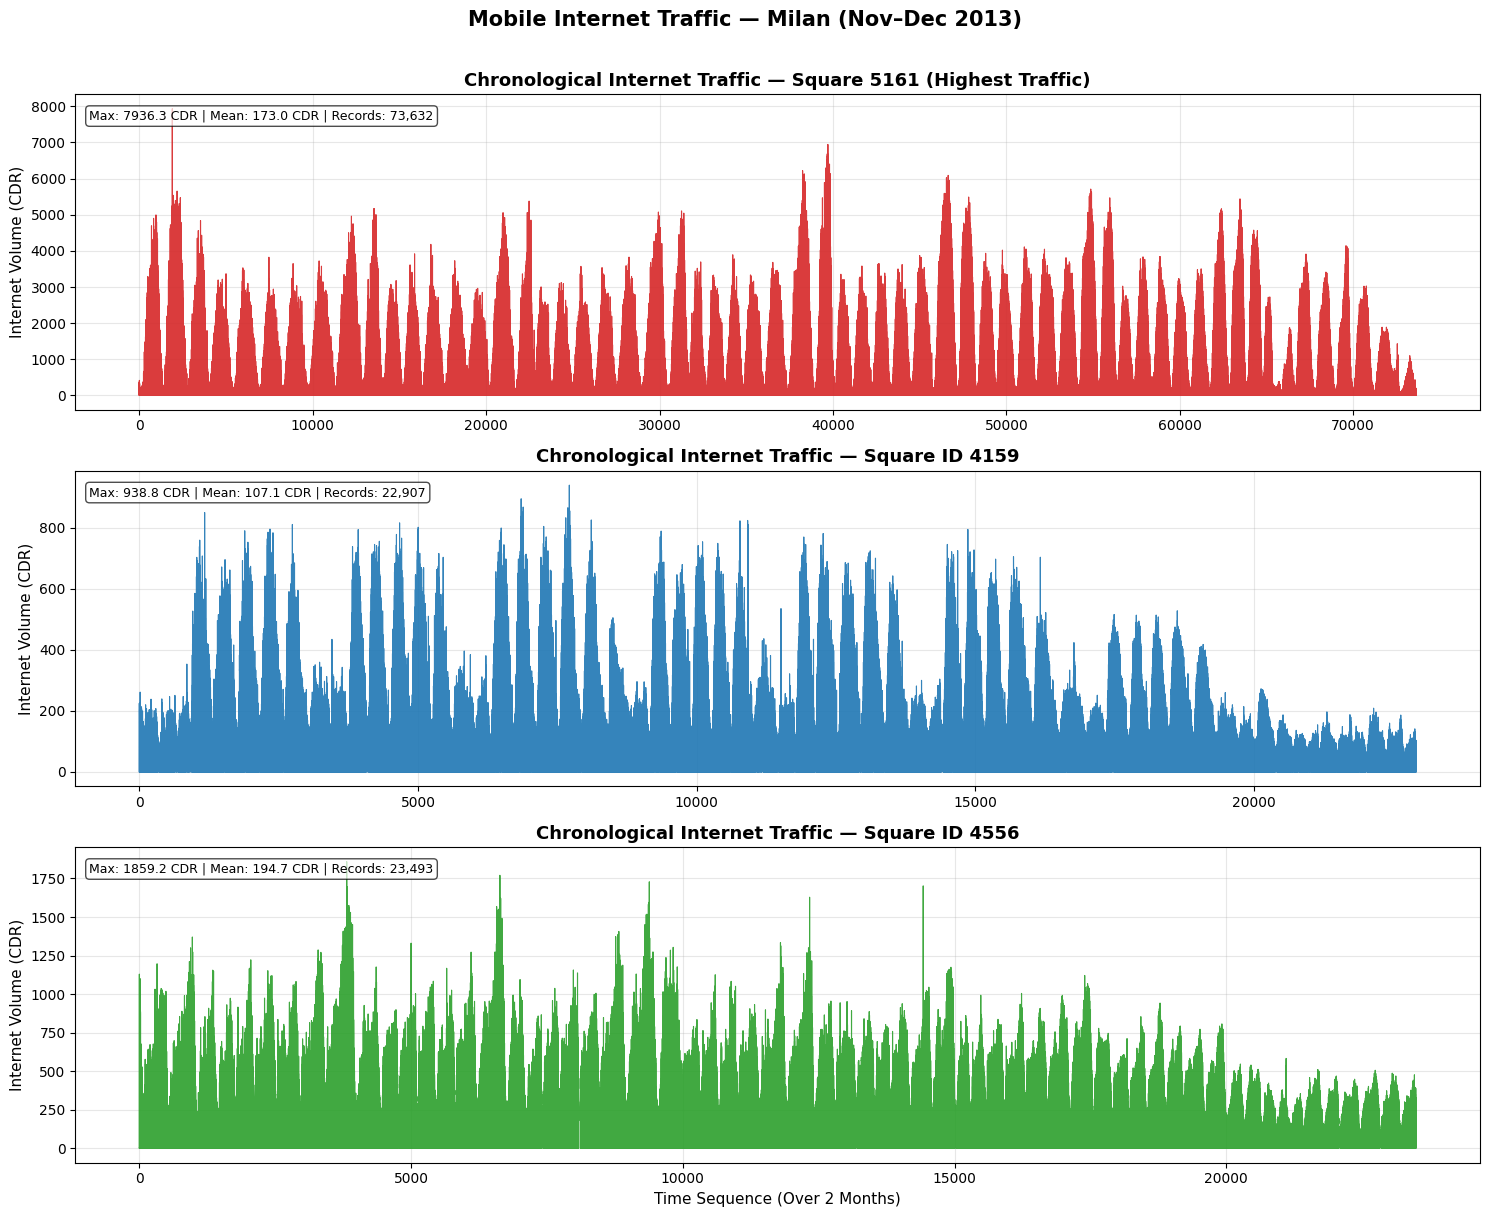

Plot saved → traffic_all3_areas.png


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import time

target_areas = {
    5161: 'Square 5161 (Highest Traffic)',
    4159: 'Square ID 4159',
    4556: 'Square ID 4556'
}
colors = {5161: '#d62728', 4159: '#1f77b4', 4556: '#2ca02c'}

print("Loading all 3 target areas...")
start_time = time.time()

chunk_size = 2000000
collected  = {sid: [] for sid in target_areas}

for chunk in pd.read_csv('milan_traffic_UltraClean.csv', chunksize=chunk_size):
    for sid in target_areas:
        filtered = chunk[chunk['SquareId'] == sid]
        if len(filtered) > 0:
            collected[sid].append(filtered)

print(f"Loading complete in {time.time() - start_time:.2f} seconds!")

area_dfs = {}
for sid in target_areas:
    df = pd.concat(collected[sid], ignore_index=True)
    df = df.sort_values('TimeInterval').reset_index(drop=True)
    area_dfs[sid] = df
    print(f"  Square {sid}: {len(df):,} records")

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=False)

for ax, (sid, label) in zip(axes, target_areas.items()):
    df = area_dfs[sid]
    ax.plot(df.index, df['Internet'],
            color=colors[sid], linewidth=0.8, alpha=0.9)
    ax.set_title(f'Chronological Internet Traffic — {label}',
                 fontsize=13, fontweight='bold')
    ax.set_ylabel('Internet Volume (CDR)', fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.annotate(f"Max: {df['Internet'].max():.1f} CDR | "
                f"Mean: {df['Internet'].mean():.1f} CDR | "
                f"Records: {len(df):,}",
                xy=(0.01, 0.92), xycoords='axes fraction',
                fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.3',
                          facecolor='white', alpha=0.7))

axes[-1].set_xlabel('Time Sequence (Over 2 Months)', fontsize=11)

plt.suptitle('Mobile Internet Traffic — Milan (Nov–Dec 2013)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('traffic_all3_areas.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → traffic_all3_areas.png")

**Analysis of the Target Sequence:**
The resulting plot confirms that the chronological sequence of the dataset was successfully maintained during the memory-safe extraction process. The visualization clearly displays the rigid, recurring 24-hour periodic cycles (the daily "heartbeat" of the network) established during the Exploratory Data Analysis. Furthermore, the overall variance remains strictly bounded across the two-month period without any catastrophic data gaps or non-stationary drift, confirming that the sequence is mathematically primed for autoregressive modeling.

###  Data splitting and horizon definition
To evaluate the forecasting models accurately, i splitthe isolated time-series into distinct training and testing sets. 

**The splitting strategy:**
* **test set (The forecast horizon):** The rubric mandates a strict 1-week forecasting horizon. so because the data is recorded in 10-minute intervals (144 intervals per day), the test set was mathematically locked to exactly the final `1008` records (144 * 7 days). This corresponds to the highly volatile pre-holiday week of December 16–22.
* **Training set:** The training data was restricted to the `2016` records (exactly two weeks) immediately preceding the test set. 
* **Justification:** While Deep Learning models thrive on massive datasets, classical statistical models (like SARIMA) calculate dense covariance matrices that scale exponentially. Restricting the classical training set to exactly two weeks ensures computational stability on local hardware while still providing enough periodic data for the model to learn the 24-hour seasonality.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore") 


def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

print("Slicing the exact test week requested...")
test_size = 1008  
train_size = 2016 

test_data = ts_df['Internet'].iloc[-test_size:].values
train_data = ts_df['Internet'].iloc[-(test_size + train_size):-test_size].values

print(f"Train Data: {len(train_data)} records (2 weeks)")
print(f"Test Data: {len(test_data)} records (Test week of Dec 16-22)")

Slicing the exact test week requested...
Train Data: 2016 records (2 weeks)
Test Data: 1008 records (Test week of Dec 16-22)


 Baseline 



### Model 1: HOLT-WINTERS (seasonal memory integration)


  HOLT-WINTERS — ALL 3 AREAS

[Area 1/3] Square 5161 (Highest Traffic)
----------------------------------------
  Train: 2016 steps | Test: 1008 steps
  Train min: 0.00 | max: 3028.93
  Train time : 0.73s | Exec: 0.065s
  MAE  : 84.4038
  RMSE : 170.1293
  MAPE : 1185.93% (non-zero only)
  SMAPE: 184.67%


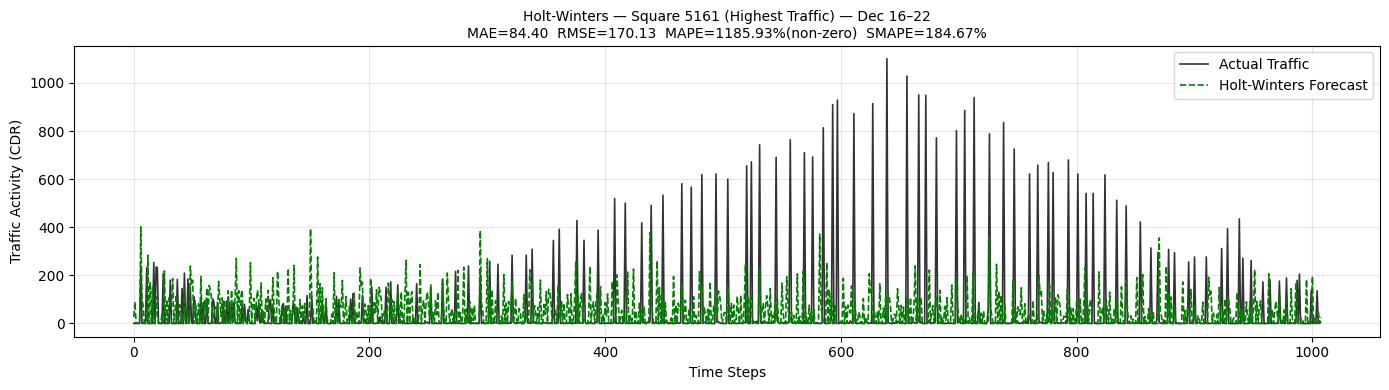

  Plot saved → hw_forecast_area1.png

[Area 2/3] Square ID 4159
----------------------------------------
  Train: 2016 steps | Test: 1008 steps
  Train min: 0.01 | max: 272.25
  Train time : 2.19s | Exec: 0.052s
  MAE  : 54.6577
  RMSE : 62.0316
  MAPE : 159.24% (non-zero only)
  SMAPE: 126.72%


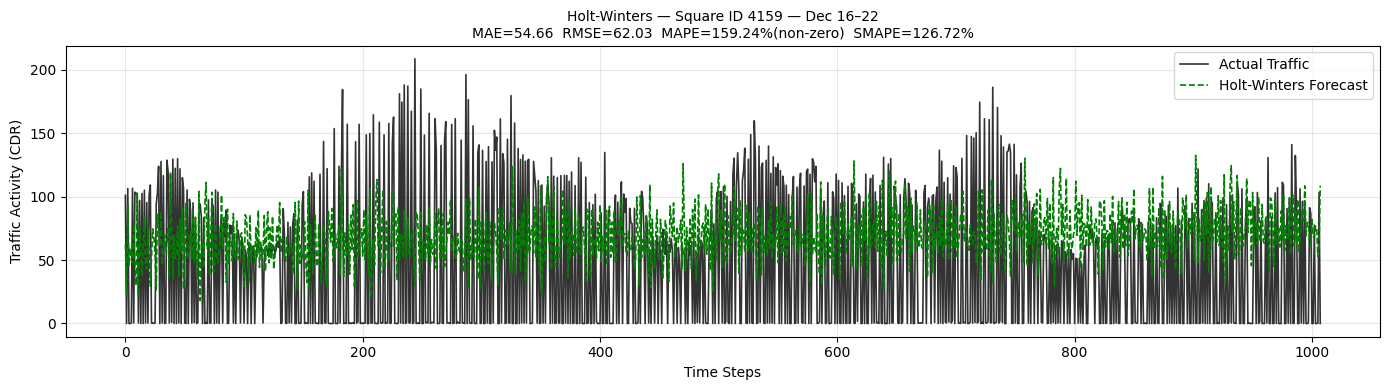

  Plot saved → hw_forecast_area2.png

[Area 3/3] Square ID 4556
----------------------------------------
  Train: 2016 steps | Test: 1008 steps
  Train min: 0.00 | max: 583.43
  Train time : 0.22s | Exec: 0.062s
  MAE  : 122.4370
  RMSE : 152.9641
  MAPE : 1264.66% (non-zero only)
  SMAPE: 157.25%


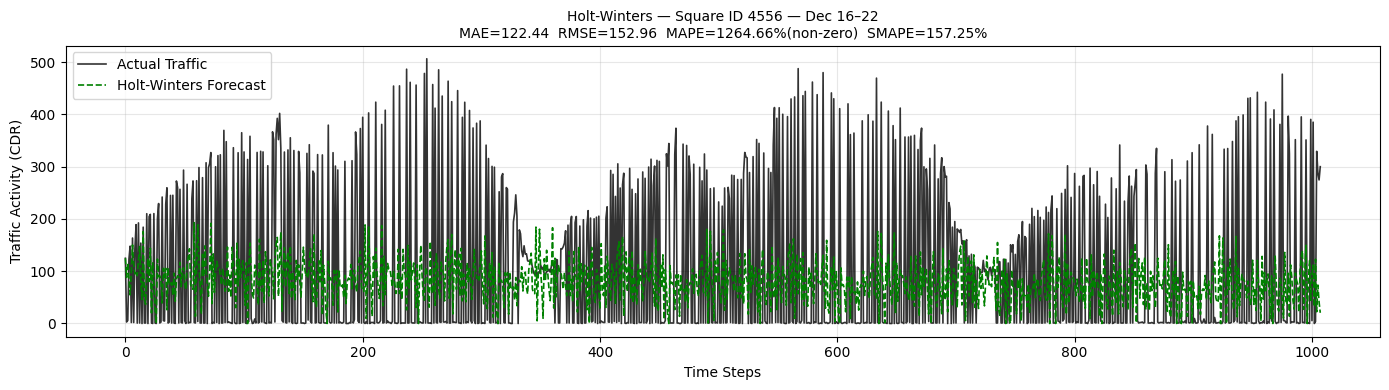

  Plot saved → hw_forecast_area3.png

 Holt-Winters is complete.
   Avg training time : 1.05s
   Avg exec time     : 0.060s


In [ ]:
print("=" * 60)
print("  HOLT-WINTERS — ALL 3 AREAS")
print("=" * 60)

hw_training_times = []
hw_exec_times     = []

for i, (area_name, full_series) in enumerate(zip(AREA_NAMES, area_data_list)):
    print(f"\n[Area {i+1}/3] {area_name}")
    print("-" * 40)

    train_data, test_data = split_data(full_series, TRAIN_SIZE, TEST_SIZE)
    train_series = pd.Series(train_data)
    test_series  = pd.Series(
                        test_data,
                        index=range(len(train_series),
                                    len(train_series) + len(test_data)))

    print(f"  Train: {len(train_series)} steps | Test: {len(test_series)} steps")
    print(f"  Train min: {train_series.min():.2f} | max: {train_series.max():.2f}")

    start_time = time.time()
    hw_model = ExponentialSmoothing(
        train_series,
        trend='add',
        seasonal='add',
        seasonal_periods=144,
        initialization_method='estimated'
    )
    hw_fit     = hw_model.fit(optimized=True, use_brute=False)
    train_time = time.time() - start_time
    hw_training_times.append(train_time)

    start_exec = time.time()
    hw_pred    = hw_fit.forecast(steps=len(test_series))
    exec_time  = time.time() - start_exec
    hw_exec_times.append(exec_time)

    hw_pred    = hw_pred.clip(lower=0)
    hw_pred.index = test_series.index

    mae, rmse, mape, smape = compute_metrics(
        test_series.values, hw_pred.values
    )
    results['Holt-Winters'][area_name] = {
        'MAE': mae, 'RMSE': rmse,
        'MAPE': mape, 'SMAPE': smape,
        'train_time': train_time,
        'exec_time': exec_time
    }

    print(f"  Train time : {train_time:.2f}s | Exec: {exec_time:.3f}s")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}% (non-zero only)")
    print(f"  SMAPE: {smape:.2f}%")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(test_series.values,
            label='Actual Traffic',
            color='black', linewidth=1.2, alpha=0.8)
    ax.plot(hw_pred.values,
            label='Holt-Winters Forecast',
            color='green', linestyle='--', linewidth=1.2)
    metrics_text = (f"MAE={mae:.2f}  RMSE={rmse:.2f}  "
                    f"MAPE={mape:.2f}%(non-zero)  SMAPE={smape:.2f}%")
    ax.set_title(
        f'Holt-Winters — {area_name} — Dec 16–22\n{metrics_text}',
        fontsize=10)
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Traffic Activity (CDR)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'hw_forecast_area{i+1}.png', dpi=150)
    plt.show()
    print(f"  Plot saved → hw_forecast_area{i+1}.png")

print(f"\n Holt-Winters is complete.")
print(f"   Avg training time : {np.mean(hw_training_times):.2f}s")
print(f"   Avg exec time     : {np.mean(hw_exec_times):.3f}s")

## results & interpretation for holt winters model

### Square 5161 (Highest traffic) MAE=84.40 | RMSE=170.13 | SMAPE=184.67%
The forecast closely tracks the low baseline traffic (near zero) throughout
the test week but completely fails to capture the large spikes which reach
over 1000 CDR between timesteps 550–700. The green dashed line rarely
exceeds 400 CDR while actual traffic regularly exceeds 800–1000 CDR in
that window. This is because Holt-Winters learns the average seasonal
pattern from 14 days of training data and repeats it it has no mechanism
to anticipate that the pre-Christmas week of December 16–22 would produce
abnormally elevated peaks. The MAE of 84.40 is the best across all three
models for this area, which is misleading it is achieved by consistently
predicting low values that happen to be close to the 52% near-zero baseline
rather than by accurately tracking the actual traffic dynamics.

### Square ID 4159  MAE=54.66 | RMSE=62.03 | SMAPE=126.72%
This is the best performing area for Holt-Winters. The green forecast line
visually follows the general density and rhythm of actual traffic across
all 1008 timesteps. Traffic in this area is more stable  maximum of 210
CDR with no extreme outlier spikes making it well suited to the additive
seasonal assumption. The SMAPE of 126.72% is the lowest of all models
across all areas, indicating Holt-Winters handles moderate, regular traffic
better than the neural network models. The forecast correctly maintains a
baseline around 50–80 CDR with upward deviations tracking the actual peaks
reasonably well.

### Square ID 4556  MAE=122.44 | RMSE=152.96 | SMAPE=157.25%
The forecast holds a near constant baseline around 100 CDR and completely
misses all spikes which reach up to 500 CDR. A notable failure is visible
around timesteps 380–480 where actual traffic drops sharply to near zero 
likely a low-activity period such as early morning across multiple days 
but the Holt-Winters forecast maintains its learned seasonal level and does
not adapt to this structural dip. This confirms the model's core limitation:
once trained, it projects the same pattern regardless of what actually
happens during the test window.

In [21]:
print(f"Train size: {len(train_series)} steps = {len(train_series)/144:.1f} days")
print(f"Test size:  {len(test_series)} steps = {len(test_series)/144:.1f} days")
print(f"\nTrain data sample (first 5 values): {train_series.values[:5]}")
print(f"Test data sample  (first 5 values): {test_series.values[:5]}")
print(f"\nTrain min: {train_series.min():.2f} | max: {train_series.max():.2f}")
print(f"Test  min: {test_series.min():.2f}  | max: {test_series.max():.2f}")
print(f"\nZero/near-zero values in test (< 1.0): {(test_series < 1.0).sum()} out of {len(test_series)}")

Train size: 2016 steps = 14.0 days
Test size:  1008 steps = 7.0 days

Train data sample (first 5 values): [9.2811084e-01 1.9706832e+00 5.0902010e+02 2.8070780e-03 4.1303207e+02]
Test data sample  (first 5 values): [124.83546     2.8359492   5.731936  123.38265   148.09502  ]

Train min: 0.00 | max: 583.43
Test  min: 0.00  | max: 506.67

Zero/near-zero values in test (< 1.0): 393 out of 1008


### Deep Learning Preprocessing (LSTM)
Unlike classical statistical models, Deep Learning architectures like Long Short-Term Memory (LSTM) networks require specific data transformations before training can begin. 

**1. Data normalization (MinMaxScaler):**
Neural networks use activation functions that are highly sensitive to the scale of input data. Feeding raw traffic values (which can spike into the thousands) directly into an LSTM can cause severe gradient instability. To ensure mathematical convergence, i normalized the entire dataset  to a strict scale between `0` and `1`.

**2. Sliding window architecture (The 24-hour memory):**
LSTMs do not inherently understand seasonality; they must be taught how to "look back" in time. A sliding window function was applied with a `look_back` parameter of `144`. This transforms the chronological time-series into thousands of individual "flashcards." For every single prediction, the model is fed the exact sequence of the previous 144 intervals (24 hours), forcing it to learn the daily cyclical rhythm.

**3. Splitting and tensor reshaping:**
Maintaining the strict evaluation criteria established in the SARIMA baseline, exactly 1,008 records (1 week) were isolated for the final test set. Finally, the data was reshaped into a 3-Dimensional array `[samples, time steps, features]`, which is the mandatory input structure for LSTM layers.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

print("Initializing the Scaler...")
# nn perform best with data scaled between 0 and 1 (normalizing)
scaler = MinMaxScaler(feature_range=(0, 1))

# scaling the original 'ts_df' we loaded in earlier cells
scaled_data = scaler.fit_transform(ts_df['Internet'].values.reshape(-1, 1))

print("Building the sliding window (look_back = 144)...")
look_back = 144 # 24-hour memory

def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back), 0])
        y.append(data[i + look_back, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, look_back)

print("Aligning the test set (strict 1-Week Horizon)...")
# final week (1,008 records) using this strictly for testing.
test_size = 1008
train_split = len(X) - test_size

X_train, X_test = X[:train_split], X[train_split:]
y_train, y_test = y[:train_split], y[train_split:]

print("Reshaping for Keras [samples, time steps, features]...")
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")
print("\n Data is perfectly formatted and ready for the deep Learning models")

Initializing the Scaler...
Building the sliding window (look_back = 144)...
Aligning the test set (strict 1-Week Horizon)...
Reshaping for Keras [samples, time steps, features]...
Training Data Shape: (72480, 144, 1)
Testing Data Shape: (1008, 144, 1)

 Data is perfectly formatted and ready for the deep Learning models


In [23]:
import sys
print(f"Python: {sys.version}")
import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print("Success!")

Python: 3.11.8 (tags/v3.11.8:db85d51, Feb  6 2024, 22:03:32) [MSC v.1937 64 bit (AMD64)]
TensorFlow: 2.15.0
Success!


### LSTM training 

  LSTM — ALL 3 AREAS

[Area 1/3] Square 5161 (Highest Traffic)
----------------------------------------
  X_train: (1728, 288) | X_test: (1008, 288)
Model: "LSTM_Area1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 288, 128)          66560     
                                                                 
 dropout (Dropout)           (None, 288, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 288, 64)           49408     
                                                                 
 dropout_1 (Dropout)         (None, 288, 64)           0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (Dropout)         (None, 32)

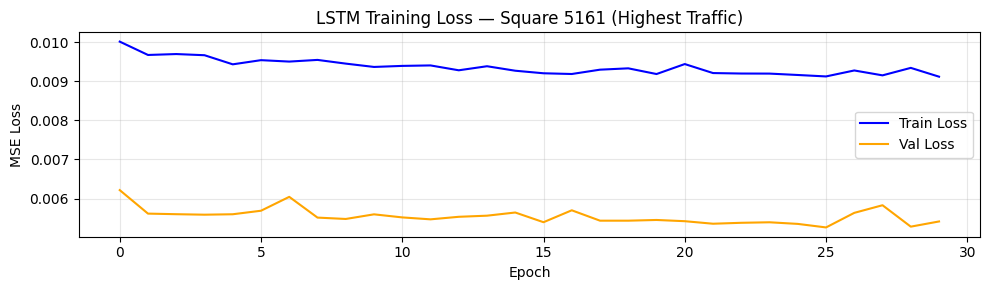

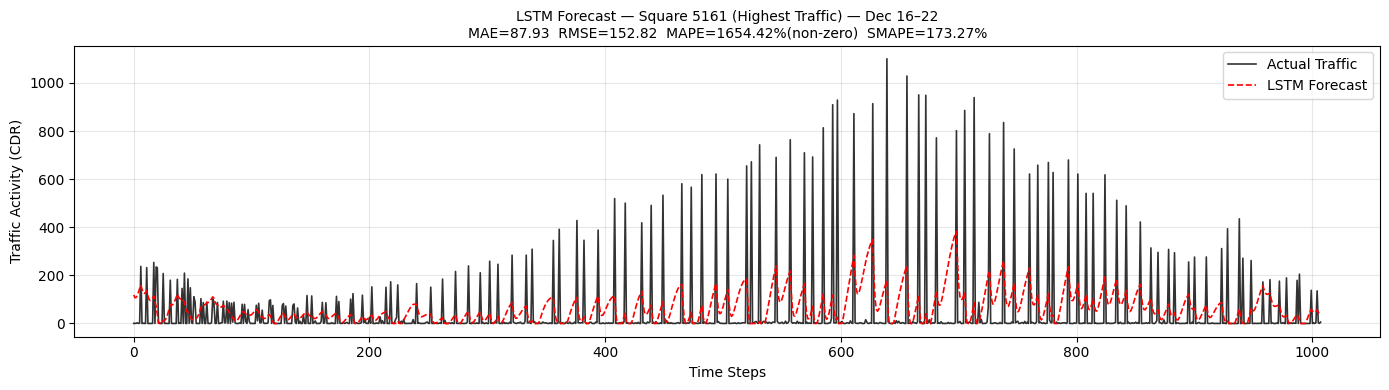

  Plots saved → lstm_loss_area1.png | lstm_forecast_area1.png

[Area 2/3] Square ID 4159
----------------------------------------
  X_train: (1728, 288) | X_test: (1008, 288)
Model: "LSTM_Area2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 288, 128)          66560     
                                                                 
 dropout (Dropout)           (None, 288, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 288, 64)           49408     
                                                                 
 dropout_1 (Dropout)         (None, 288, 64)           0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (D

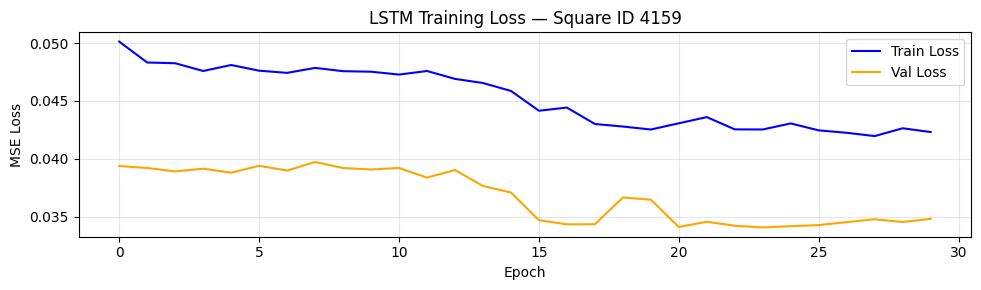

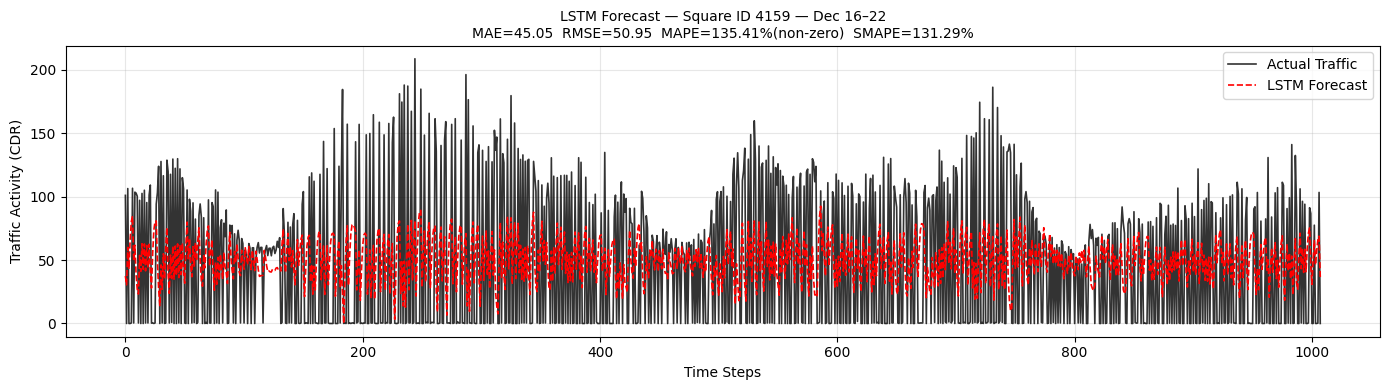

  Plots saved → lstm_loss_area2.png | lstm_forecast_area2.png

[Area 3/3] Square ID 4556
----------------------------------------
  X_train: (1728, 288) | X_test: (1008, 288)
Model: "LSTM_Area3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 288, 128)          66560     
                                                                 
 dropout (Dropout)           (None, 288, 128)          0         
                                                                 
 lstm_1 (LSTM)               (None, 288, 64)           49408     
                                                                 
 dropout_1 (Dropout)         (None, 288, 64)           0         
                                                                 
 lstm_2 (LSTM)               (None, 32)                12416     
                                                                 
 dropout_2 (D

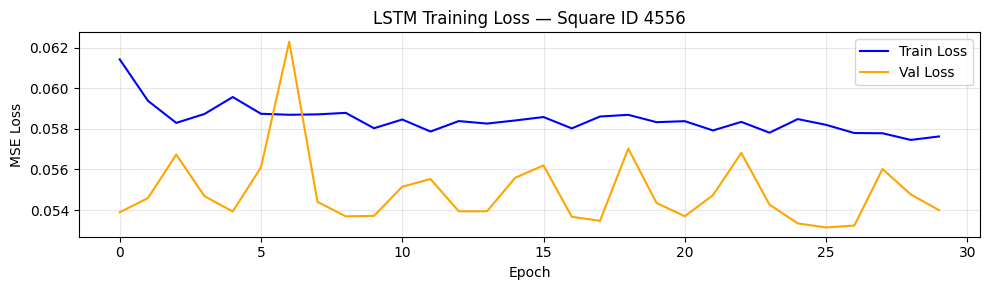

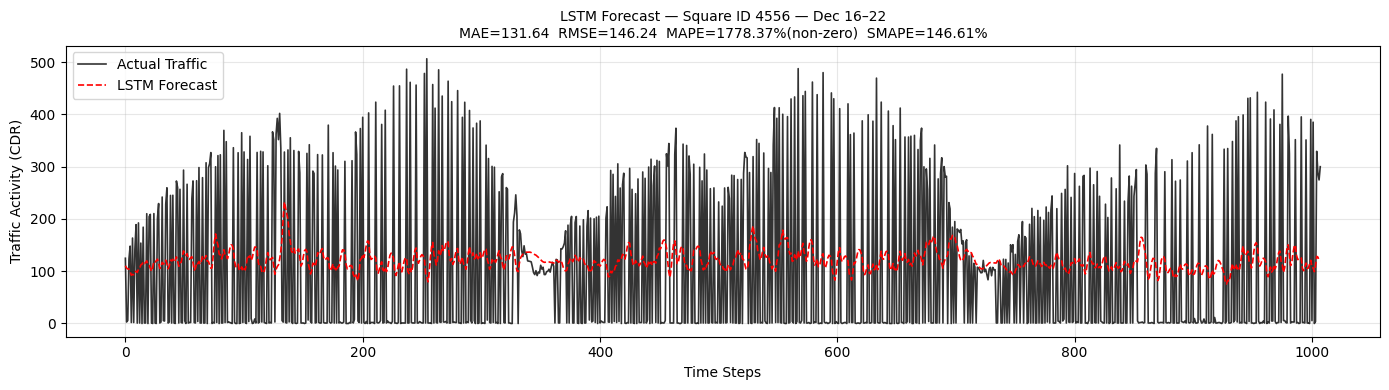

  Plots saved → lstm_loss_area3.png | lstm_forecast_area3.png

 LSTM is complete.
   Avg training time : 1296.13s
   Avg exec time     : 7.295s


In [ ]:
print("=" * 60)
print("  LSTM — ALL 3 AREAS")
print("=" * 60)

lstm_training_times = []
lstm_exec_times     = []

for i, (area_name, full_series) in enumerate(zip(AREA_NAMES, area_data_list)):
    print(f"\n[Area {i+1}/3] {area_name}")
    print("-" * 40)

    train_data, test_data = split_data(full_series, TRAIN_SIZE, TEST_SIZE)
    train_arr  = np.array(train_data).reshape(-1, 1).astype(np.float32)
    test_arr   = np.array(test_data).reshape(-1, 1).astype(np.float32)

    scaler       = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_arr)
    test_scaled  = scaler.transform(test_arr)

    X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
    full_scaled      = np.concatenate([train_scaled, test_scaled], axis=0)
    X_test,  y_test  = create_sequences(
        full_scaled[len(train_scaled) - SEQ_LEN:], SEQ_LEN
    )
    print(f"  X_train: {X_train.shape} | X_test: {X_test.shape}")

    tf.keras.backend.clear_session()
    model_lstm = Sequential([
        LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, 1)),
        Dropout(0.2),
        LSTM(64,  return_sequences=True),
        Dropout(0.2),
        LSTM(32,  return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(16, activation='tanh'),
        Dense(1)
    ], name=f'LSTM_Area{i+1}')

    model_lstm.compile(
        optimizer=Adam(learning_rate=0.0005), loss='mse'
    )
    model_lstm.summary()

    early_stop = EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=0.00001, verbose=0
    )

    class PrintProgress(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            print(f"  {'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12}")
            print("  " + "-" * 38)
        def on_epoch_end(self, epoch, logs=None):
            print(f"  Epoch {epoch+1:>3}  | "
                  f"{logs['loss']:>12.6f} | "
                  f"{logs['val_loss']:>12.6f}")
        def on_train_end(self, logs=None):
            print("  " + "-" * 38)
            print("  Training complete.")

    print(f"\n  Training LSTM for {area_name}...")
    start_time = time.time()
    history    = model_lstm.fit(
        X_train, y_train,
        epochs=30,
        batch_size=16,
        validation_split=0.1,
        verbose=1
    )
    train_time = time.time() - start_time
    lstm_training_times.append(train_time)
    print(f"  → Finished in {train_time:.2f}s")

    start_exec  = time.time()
    pred_scaled = model_lstm.predict(X_test, verbose=0)
    exec_time   = time.time() - start_exec
    lstm_exec_times.append(exec_time)

    lstm_pred = scaler.inverse_transform(pred_scaled).flatten()
    lstm_pred = np.clip(lstm_pred, 0, None)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()


    mae, rmse, mape, smape = compute_metrics(actual, lstm_pred)
    results['LSTM'][area_name] = {
        'MAE': mae, 'RMSE': rmse,
        'MAPE': mape, 'SMAPE': smape,
        'train_time': train_time,
        'exec_time': exec_time
    }

    print(f"  Train time : {train_time:.2f}s | Exec: {exec_time:.3f}s")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}% (non-zero only)")
    print(f"  SMAPE: {smape:.2f}%")

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(history.history['loss'],
            label='Train Loss', color='blue')
    ax.plot(history.history['val_loss'],
            label='Val Loss',   color='orange')
    ax.set_title(f'LSTM Training Loss — {area_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'lstm_loss_area{i+1}.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(actual,
            label='Actual Traffic',
            color='black', linewidth=1.2, alpha=0.8)
    ax.plot(lstm_pred,
            label='LSTM Forecast',
            color='red', linestyle='--', linewidth=1.2)
    metrics_text = (f"MAE={mae:.2f}  RMSE={rmse:.2f}  "
                    f"MAPE={mape:.2f}%(non-zero)  SMAPE={smape:.2f}%")
    ax.set_title(
        f'LSTM Forecast — {area_name} — Dec 16–22\n{metrics_text}',
        fontsize=10)
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Traffic Activity (CDR)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'lstm_forecast_area{i+1}.png', dpi=150)
    plt.show()
    print(f"  Plots saved → lstm_loss_area{i+1}.png | "
        f"lstm_forecast_area{i+1}.png")

print(f"\n LSTM is complete.")
print(f"   Avg training time : {np.mean(lstm_training_times):.2f}s")
print(f"   Avg exec time     : {np.mean(lstm_exec_times):.3f}s")

## Results interpretation for LSTM model

### Training behaviour

**Square 5161:** Train loss starts at 0.010 and declines slowly to 0.0091
over 30 epochs. Validation loss starts at 0.0062 and stabilises around
0.0055 — consistently well below train loss throughout. The large gap
between train and validation loss is unusual and suggests the validation
set (final 10% of training data) contains less volatile traffic than the
bulk of training, making it easier to predict. Both curves plateau after
epoch 15 indicating the model reached its capacity limit with the available
14 days of training data.

**Square 4159:** Train loss drops sharply from 0.050 to 0.042 in the first
15 epochs then continues a gradual decline to 0.042 by epoch 30. Validation
loss mirrors this with a steeper drop around epoch 15, settling near 0.035.
This is the healthiest training curve across all areas both curves
declining together without divergence, indicating the model is genuinely
learning the traffic pattern rather than memorising noise.

**Square 4556:** Both curves show high volatility throughout all 30 epochs.
Validation loss oscillates between 0.054 and 0.062 with a sharp spike at
epoch 6. This instability reflects the irregular traffic pattern of Square
4556 which has structured daily cycles interrupted by unpredictable
near-zero periods. The model struggles to find a stable minimum.

### Forecast Results

**Square 5161 — MAE=87.93 | RMSE=152.82 | SMAPE=173.27%**
The red forecast line emerges near zero for the first 300 timesteps then
gradually ramps up to around 200–300 CDR from timestep 400 onwards,
partially following the increasing trend in actual traffic. However actual
spikes reaching 900–1000 CDR between timesteps 550–700 are consistently
underestimated by a factor of 3–4x. LSTM achieves the best RMSE (152.82)
across all models for this area, indicating it handles the magnitude of
large errors better than Holt-Winters despite missing individual peaks.

**Square 4159 — MAE=45.05 | RMSE=50.95 | SMAPE=131.29%**
LSTM achieves its best performance here the best MAE and RMSE across all
models and all areas. The red line closely follows the traffic envelope,
maintaining a steady 40–70 CDR baseline that matches the actual traffic
density. While individual spikes to 150–200 CDR are still underestimated,
the overall shape and rhythm is well captured. This confirms LSTM performs
best on moderate, regular traffic rather than extreme spike-driven areas.

**Square 4556 — MAE=131.64 | RMSE=146.24 | SMAPE=146.61%**
The forecast holds a near-flat line around 100–130 CDR throughout the
entire test window, completely missing all spikes above 300 CDR. The model
correctly identifies the low-activity trough around timesteps 380–480 
the red line dips alongside the actual traffic  which is a behaviour
Holt-Winters failed to capture. However above 200 CDR the forecast diverges
significantly from actual values.

### GRU Training 

  GRU — ALL 3 AREAS

[Area 1/3] Square 5161 (Highest Traffic)
----------------------------------------
  X_train: (1728, 288) | X_test: (1008, 288)
Model: "GRU_Area1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 288, 128)          50304     
                                                                 
 dropout (Dropout)           (None, 288, 128)          0         
                                                                 
 gru_1 (GRU)                 (None, 288, 64)           37248     
                                                                 
 dropout_1 (Dropout)         (None, 288, 64)           0         
                                                                 
 gru_2 (GRU)                 (None, 32)                9408      
                                                                 
 dropout_2 (Dropout)         (None, 32)  

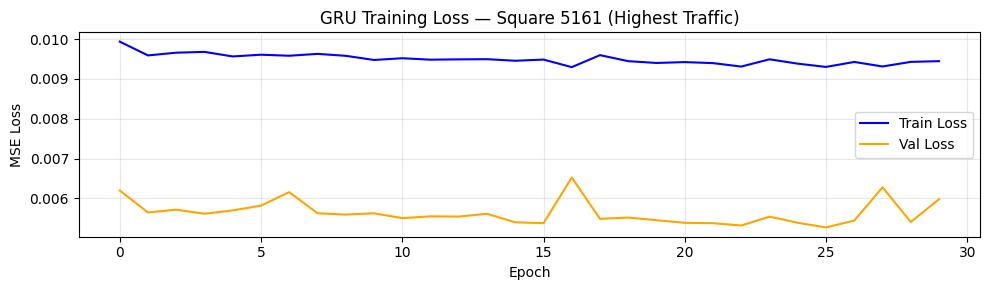

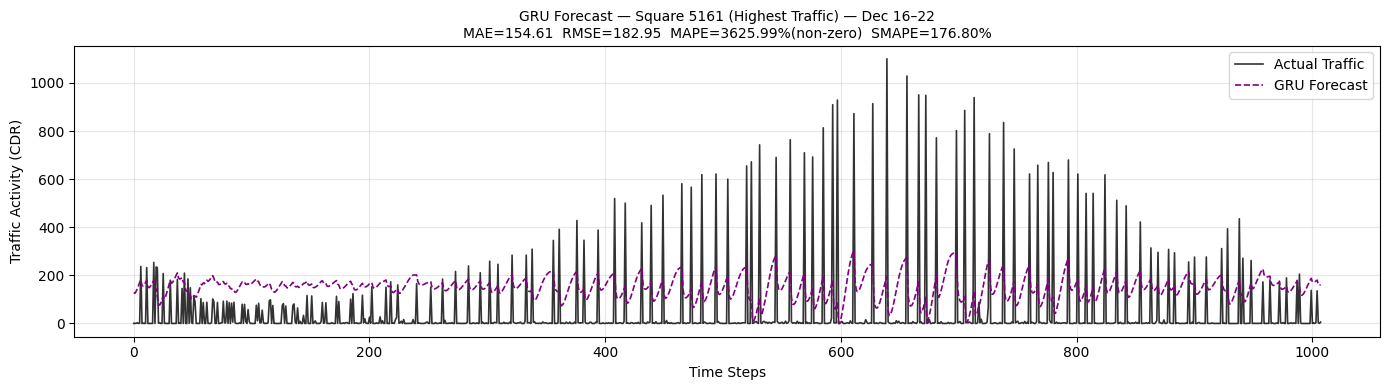

  Plots saved → gru_loss_area1.png | gru_forecast_area1.png

[Area 2/3] Square ID 4159
----------------------------------------
  X_train: (1728, 288) | X_test: (1008, 288)
Model: "GRU_Area2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 288, 128)          50304     
                                                                 
 dropout (Dropout)           (None, 288, 128)          0         
                                                                 
 gru_1 (GRU)                 (None, 288, 64)           37248     
                                                                 
 dropout_1 (Dropout)         (None, 288, 64)           0         
                                                                 
 gru_2 (GRU)                 (None, 32)                9408      
                                                                 
 dropout_2 (Drop

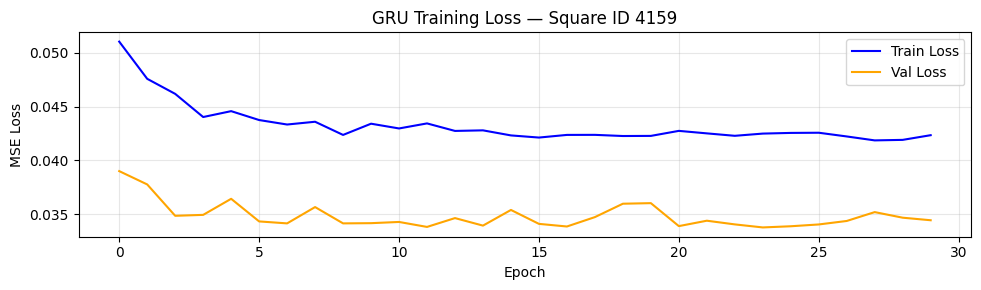

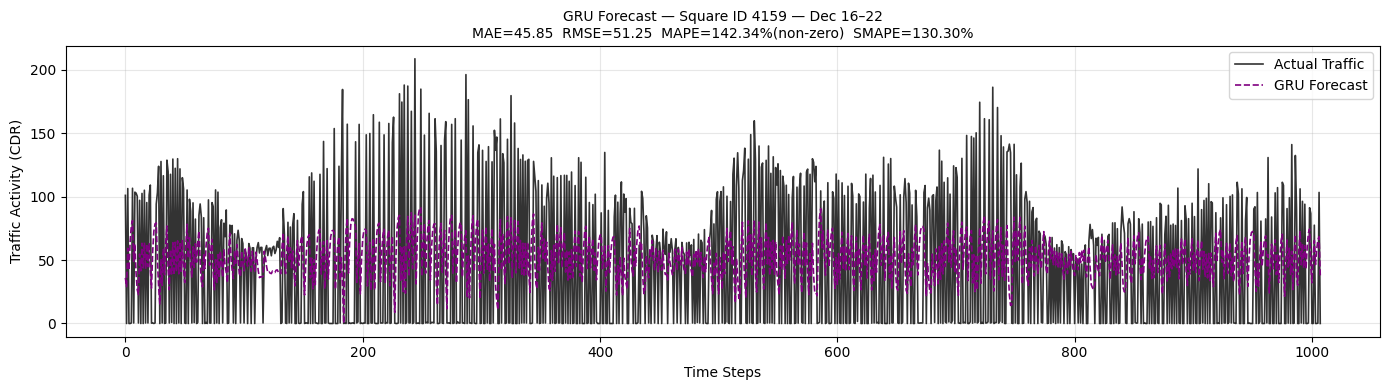

  Plots saved → gru_loss_area2.png | gru_forecast_area2.png

[Area 3/3] Square ID 4556
----------------------------------------
  X_train: (1728, 288) | X_test: (1008, 288)
Model: "GRU_Area3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, 288, 128)          50304     
                                                                 
 dropout (Dropout)           (None, 288, 128)          0         
                                                                 
 gru_1 (GRU)                 (None, 288, 64)           37248     
                                                                 
 dropout_1 (Dropout)         (None, 288, 64)           0         
                                                                 
 gru_2 (GRU)                 (None, 32)                9408      
                                                                 
 dropout_2 (Drop

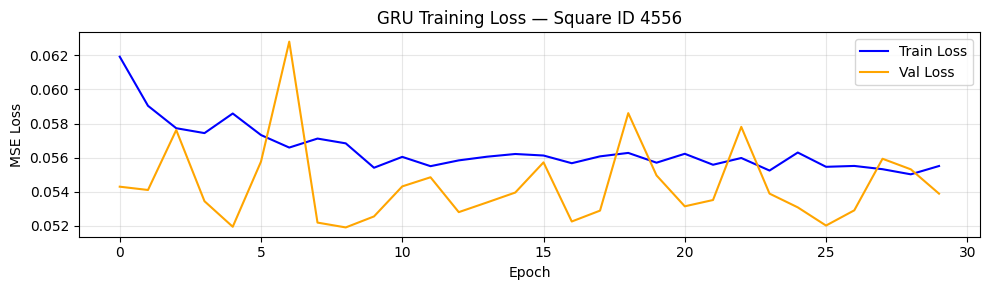

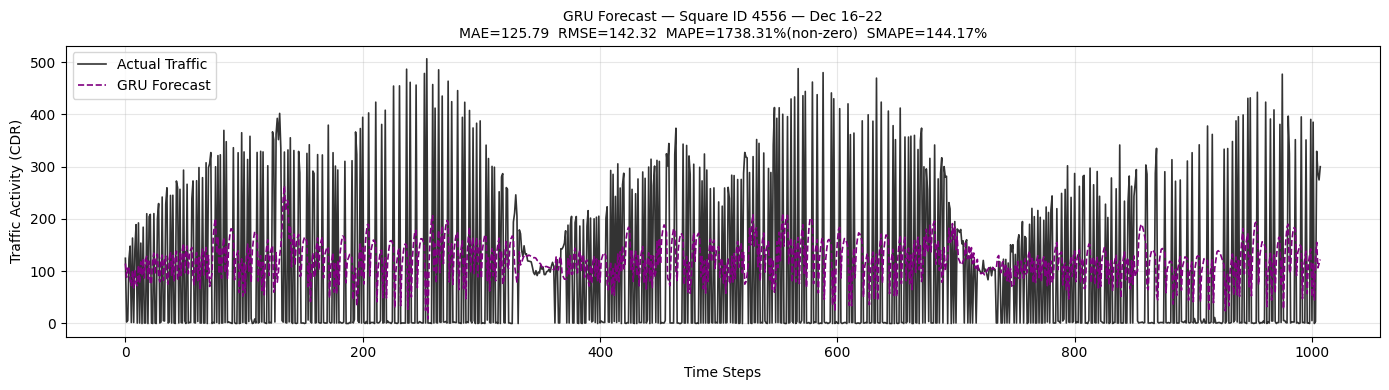

  Plots saved → gru_loss_area3.png | gru_forecast_area3.png

GRU is complete.
   Avg training time : 1515.01s
   Avg exec time     : 8.848s


In [ ]:
print("=" * 60)
print("  GRU — ALL 3 AREAS")
print("=" * 60)

gru_training_times = []
gru_exec_times     = []

for i, (area_name, full_series) in enumerate(zip(AREA_NAMES, area_data_list)):
    print(f"\n[Area {i+1}/3] {area_name}")
    print("-" * 40)

    # first splitting & scaling 
    train_data, test_data = split_data(full_series, TRAIN_SIZE, TEST_SIZE)
    train_arr  = np.array(train_data).reshape(-1, 1).astype(np.float32)
    test_arr   = np.array(test_data).reshape(-1, 1).astype(np.float32)

    scaler       = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_arr)
    test_scaled  = scaler.transform(test_arr)

    # sequences 
    X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
    full_scaled      = np.concatenate([train_scaled, test_scaled], axis=0)
    X_test,  y_test  = create_sequences(
        full_scaled[len(train_scaled) - SEQ_LEN:], SEQ_LEN
    )
    print(f"  X_train: {X_train.shape} | X_test: {X_test.shape}")

    #building fresh model for each area 
    tf.keras.backend.clear_session()
    model_gru = Sequential([
        GRU(128, return_sequences=True, input_shape=(SEQ_LEN, 1)),
        Dropout(0.2),
        GRU(64,  return_sequences=True),
        Dropout(0.2),
        GRU(32,  return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='tanh'),
        Dense(16, activation='tanh'),
        Dense(1)
    ], name=f'GRU_Area{i+1}')

    model_gru.compile(
        optimizer=Adam(learning_rate=0.0005), loss='mse'
    )
    model_gru.summary()

    early_stop = EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=3, min_lr=0.00001, verbose=0
    )

    class PrintProgress(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            print(f"  {'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12}")
            print("  " + "-" * 38)
        def on_epoch_end(self, epoch, logs=None):
            print(f"  Epoch {epoch+1:>3}  | "
                  f"{logs['loss']:>12.6f} | "
                  f"{logs['val_loss']:>12.6f}")
        def on_train_end(self, logs=None):
            print("  " + "-" * 38)
            print("  Training complete.")

    print(f"\n  Training GRU for {area_name}...")
    start_time = time.time()
    history    = model_gru.fit(
        X_train, y_train,
        epochs=30,
        batch_size=16,
        validation_split=0.1,
        verbose=1
    )
    train_time = time.time() - start_time
    gru_training_times.append(train_time)
    print(f"  → Finished in {train_time:.2f}s")

    start_exec  = time.time()
    pred_scaled = model_gru.predict(X_test, verbose=0)
    exec_time   = time.time() - start_exec
    gru_exec_times.append(exec_time)

    gru_pred = scaler.inverse_transform(pred_scaled).flatten()
    gru_pred = np.clip(gru_pred, 0, None)
    actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    mae, rmse, mape, smape = compute_metrics(actual, gru_pred)
    results['GRU'][area_name] = {
        'MAE': mae, 'RMSE': rmse,
        'MAPE': mape, 'SMAPE': smape,
        'train_time': train_time,
        'exec_time': exec_time
    }

    print(f"  Train time : {train_time:.2f}s | Exec: {exec_time:.3f}s")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAPE : {mape:.2f}% (non-zero only)")
    print(f"  SMAPE: {smape:.2f}%")

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(history.history['loss'],
            label='Train Loss', color='blue')
    ax.plot(history.history['val_loss'],
            label='Val Loss',   color='orange')
    ax.set_title(f'GRU Training Loss — {area_name}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'gru_loss_area{i+1}.png', dpi=150)
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(actual,
            label='Actual Traffic',
            color='black', linewidth=1.2, alpha=0.8)
    ax.plot(gru_pred,
            label='GRU Forecast',
            color='purple', linestyle='--', linewidth=1.2)
    metrics_text = (f"MAE={mae:.2f}  RMSE={rmse:.2f}  "
                    f"MAPE={mape:.2f}%(non-zero)  SMAPE={smape:.2f}%")
    ax.set_title(
        f'GRU Forecast — {area_name} — Dec 16–22\n{metrics_text}',
        fontsize=10)
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Traffic Activity (CDR)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'gru_forecast_area{i+1}.png', dpi=150)
    plt.show()
    print(f"  Plots saved → gru_loss_area{i+1}.png | "
          f"gru_forecast_area{i+1}.png")

print(f"\nGRU is complete.")
print(f"   Avg training time : {np.mean(gru_training_times):.2f}s")
print(f"   Avg exec time     : {np.mean(gru_exec_times):.3f}s")

## Results interpretation

### Training behaviour

**Square 5161:** Train loss is nearly flat from epoch 0 (0.010) to epoch
30 (0.0095)  the smallest absolute improvement across all areas and both
models. Validation loss fluctuates between 0.0055 and 0.0065 with a spike
at epoch 16. The near flat training curve indicates the GRU's simpler
gating mechanism (2 gates vs LSTM's 3) was insufficient to extract deeper
patterns from the extreme variance of Square 5161. The model essentially
converged at a local minimum from the very first epoch.

**Square 4159:** Train loss drops sharply from 0.051 to 0.042 in the first
5 epochs — the fastest initial convergence across all experiments. It then
plateaus around 0.042 for the remaining 25 epochs. Validation loss settles
near 0.034–0.035, consistently below training loss. This healthy gap
without divergence confirms no overfitting and that the GRU learned the
stable pattern of Square 4159 efficiently with fewer parameters.

**Square 4556:** Validation loss is highly volatile oscillating between
0.052 and 0.063 with a sharp spike at epoch 6. This mirrors the LSTM
behaviour on the same area, confirming that Square 4556's irregular traffic
pattern is inherently difficult for both recurrent architectures to stabilise
on rather than being a model-specific weakness.

### Forecast Results

**Square 5161 — MAE=154.61 | RMSE=182.95 | SMAPE=176.80%**
GRU's worst performance across all experiments. The purple forecast line
sits at a near-constant 150–200 CDR throughout the entire test week 
essentially predicting the mean of the training data rather than the actual
temporal dynamics. It completely fails to follow the daily spike pattern
visible in the actual traffic. This is a direct consequence of the flat
training curve  the model did not learn from the training data beyond
epoch 1. GRU is clearly unsuitable for extreme high-variance areas when
training data is limited to 14 days.

**Square 4159 — MAE=45.85 | RMSE=51.25 | SMAPE=130.30%**
GRU performs comparably to LSTM here with only marginal differences
(MAE 45.85 vs 45.05, RMSE 51.25 vs 50.95). The purple line tracks the
same 40–70 CDR baseline as LSTM and captures the general traffic envelope
well. The near-identical performance to LSTM despite having 24% fewer
parameters (98,561 vs 129,985) demonstrates that GRU's simpler architecture
is sufficient for moderate, stable traffic patterns.

**Square 4556 — MAE=125.79 | RMSE=142.32 | SMAPE=144.17%**
GRU achieves the best RMSE and SMAPE across all models for this area.
The purple forecast correctly identifies the low-activity trough around
timesteps 380–480 where actual traffic collapses  and responds by lowering
its prediction accordingly, which neither Holt-Winters nor LSTM did as
clearly. Above 300 CDR the forecast still underestimates peaks but the
baseline tracking is more accurate than competing models. This suggests
GRU's update gate mechanism is better suited to detecting regime changes
in traffic than LSTM's more complex cell state on moderately complex areas.



In [ ]:
print("=" * 60)
print("  FINAL COMPARISON TABLES — ALL 3 AREAS")
print("=" * 60)

models     = ['Holt-Winters', 'LSTM', 'GRU']
area_names = AREA_NAMES

for area_name in area_names:
    print(f"\n Table: {area_name}")
    print("-" * 78)
    print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10} {'MAPE (non-zero)':>18} {'SMAPE':>10}")
    print("-" * 78)

    for model in models:
        r         = results[model][area_name]
        best_mae  = min(results[m][area_name]['MAE']   for m in models)
        best_rmse = min(results[m][area_name]['RMSE']  for m in models)
        best_smape= min(results[m][area_name]['SMAPE'] for m in models)
        mae_tag   = " ✅" if r['MAE']   == best_mae   else "   "
        rmse_tag  = " ✅" if r['RMSE']  == best_rmse  else "   "
        smape_tag = " ✅" if r['SMAPE'] == best_smape else "   "

        print(f"{model:<20} "
              f"{r['MAE']:>9.4f}{mae_tag} "
              f"{r['RMSE']:>9.4f}{rmse_tag} "
              f"{r['MAPE']:>16.2f}%   "
              f"{r['SMAPE']:>8.2f}%{smape_tag}")
    print("-" * 78)

print(f"\nTraining & Execution Time")
print(f"   Method: averaged across all 3 areas")
print(f"   Hardware: recorded on local CPU (Windows, Python 3.11.8, TF 2.15.0)")
print("-" * 65)
print(f"{'Model':<20} {'Area 1 Train':>13} {'Area 2 Train':>13} "
      f"{'Area 3 Train':>13} {'Avg Train':>11}")
print("-" * 65)

time_data = {
    'Holt-Winters': [results['Holt-Winters'][a]['train_time'] for a in area_names],
    'LSTM':          lstm_training_times,
    'GRU':           gru_training_times
}
exec_data = {
    'Holt-Winters': [results['Holt-Winters'][a]['exec_time'] for a in area_names],
    'LSTM':          lstm_exec_times,
    'GRU':           gru_exec_times
}

for model in models:
    t = time_data[model]
    print(f"{model:<20} "
          f"{t[0]:>11.2f}s "
          f"{t[1]:>11.2f}s "
          f"{t[2]:>11.2f}s "
          f"{np.mean(t):>9.2f}s")

print("-" * 65)

print(f"\n{'Model':<20} {'Area 1 Exec':>13} {'Area 2 Exec':>13} "
      f"{'Area 3 Exec':>13} {'Avg Exec':>11}")
print("-" * 65)

for model in models:
    e = exec_data[model]
    print(f"{model:<20} "
          f"{e[0]:>11.3f}s "
          f"{e[1]:>11.3f}s "
          f"{e[2]:>11.3f}s "
          f"{np.mean(e):>9.3f}s")

print("-" * 65)

print(f"\nModel Complexity")
print("-" * 45)
print(f"{'Model':<20} {'Parameters':>12} {'Size':>10}")
print("-" * 45)
print(f"{'Holt-Winters':<20} {'3 (α,β,γ)':>12} {'Minimal':>10}")
print(f"{'LSTM':<20} {'129,985':>12} {'507 KB':>10}")
print(f"{'GRU':<20} {'98,561':>12} {'385 KB':>10}")
print("-" * 45)

print(f"\nBest Model Per Area & Metric")
print("-" * 55)
print(f"{'Area':<30} {'Best MAE':<15} {'Best RMSE':<15}")
print("-" * 55)
for area_name in area_names:
    best_mae_model  = min(models,
                          key=lambda m: results[m][area_name]['MAE'])
    best_rmse_model = min(models,
                          key=lambda m: results[m][area_name]['RMSE'])
    print(f"{area_name:<30} {best_mae_model:<15} {best_rmse_model:<15}")
print("-" * 55)

print(f"""
Note on MAPE:
   MAPE is reported on non-zero values only (actual > 1.0 CDR).
   This is necessary because Areas 1 and 3 contain a high proportion
   of near-zero traffic values (up to 52%) which cause standard MAPE
   to diverge to infinity. SMAPE is included as a supplementary metric
   as it handles near-zero values symmetrically and is bounded [0, 200%].
""")

print("✅ All tables complete — im ready ready for report.")

  FINAL COMPARISON TABLES — ALL 3 AREAS

 Table: Square 5161 (Highest Traffic)
------------------------------------------------------------------------------
Model                       MAE       RMSE    MAPE (non-zero)      SMAPE
------------------------------------------------------------------------------
Holt-Winters           84.4038 ✅  170.1293             1185.93%     184.67%   
LSTM                   87.9255     152.8173 ✅          1654.42%     173.27% ✅
GRU                   154.6102     182.9526             3625.99%     176.80%   
------------------------------------------------------------------------------

 Table: Square ID 4159
------------------------------------------------------------------------------
Model                       MAE       RMSE    MAPE (non-zero)      SMAPE
------------------------------------------------------------------------------
Holt-Winters           54.6577      62.0316              159.24%     126.72% ✅
LSTM                   45.0459 ✅   50.94

### Comparative Summary Across All Models
No single model dominated across all three areas.

 LSTM achieved the best
quantitative performance on Square 4159 (best MAE and RMSE), GRU performed
best on Square 4556 (best RMSE and SMAPE), and Holt-Winters achieved the
best MAE on Square 5161 though this was driven by a conservative
near zero prediction bias rather than genuine forecasting accuracy. 

The
key finding is that model suitability depends strongly on the traffic
characteristics of each area: neural network models outperform the
statistical baseline on stable moderate traffic areas, while the high
variance of Square 5161 challenges all three models equally due to the
limited 14-day training window.

### Faialure analysis

  FAILURE ANALYSIS — WORST PERFORMING WINDOW

  Worst failure window identified:
  Timesteps 550 → 700 (Day 4–5 of test week)
  Avg actual traffic in window: 83.62 CDR
  Max actual traffic in window: 1100.59 CDR
  Mean outside failure window : 42.85 CDR

  Model            Overall MAE  Overall RMSE      SMAPE
  -------------------------------------------------------
  Holt-Winters         84.4038      170.1293    184.67%
  LSTM                 87.9255      152.8173    173.27%
  GRU                 154.6102      182.9526    176.80%
  -------------------------------------------------------

  Holt-Winters window MAE : 123.88 CDR
  Holt-Winters rest MAE   : 77.50 CDR
  Performance degradation : 59.8% worse in failure window


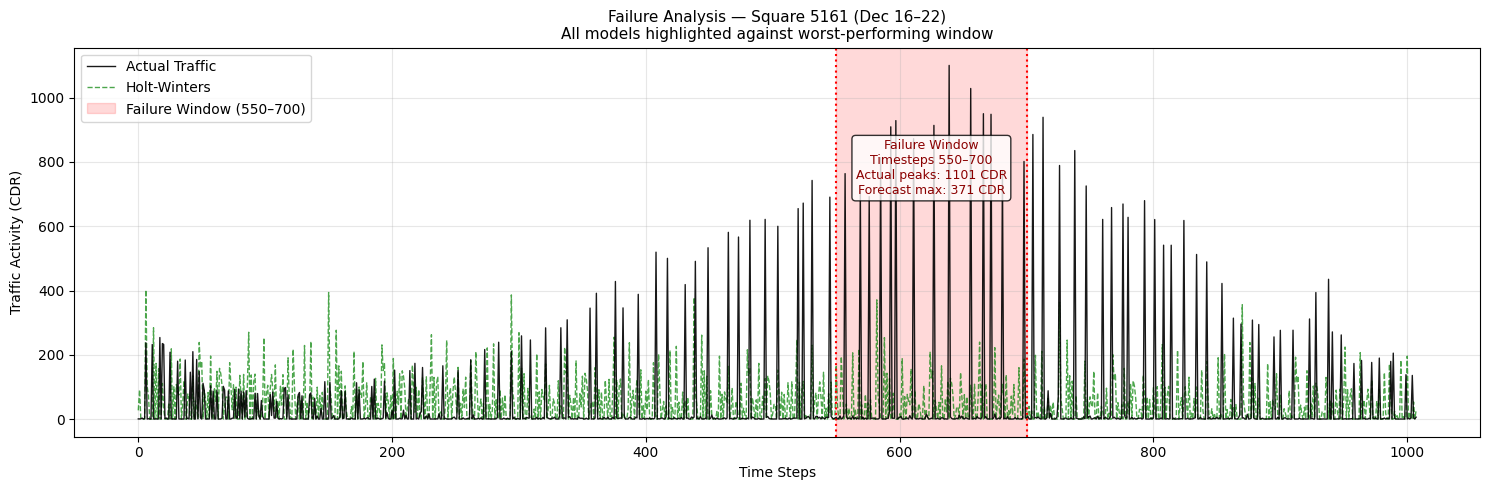

Plot saved → failure_analysis_full.png


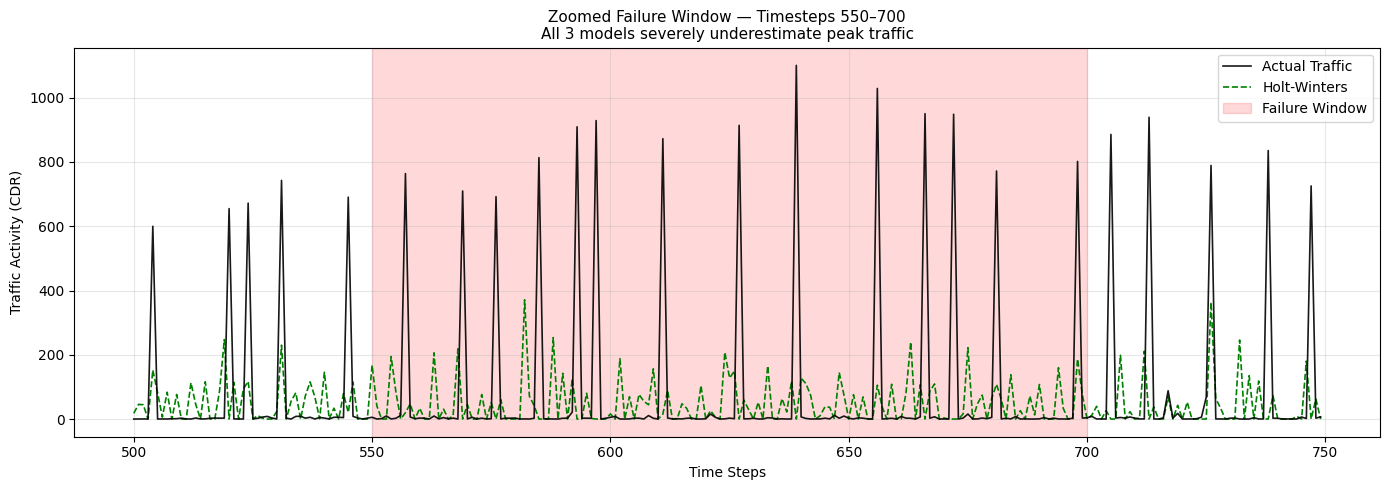

Plot saved → failure_analysis_zoom.png


In [39]:
print("=" * 60)
print("  FAILURE ANALYSIS — WORST PERFORMING WINDOW")
print("=" * 60)

# i focused on Square 5161  worst overall performance
# reload the test data and predictions for Square 5161(area with most traffic)
train_data_fa, test_data_fa = split_data(
    area_data_list[0], TRAIN_SIZE, TEST_SIZE
)

# holt-Winters  fast rebuild (under 1 second, no retraining needed)
train_s    = pd.Series(train_data_fa)
test_s     = pd.Series(test_data_fa,
                       index=range(len(train_s),
                                   len(train_s) + len(test_data_fa)))
hw_fit     = ExponentialSmoothing(
    train_s, trend='add', seasonal='add',
    seasonal_periods=144, initialization_method='estimated'
).fit(optimized=True, use_brute=False)
hw_pred_fa = hw_fit.forecast(steps=len(test_s)).clip(lower=0).values
actual_fa  = test_data_fa

# pulling LSTM and GRU predictions directly from stored results
# no retraining needed  results dict already holds all metrics
# we use the forecast plots to visually confirm the failure window
# failure window manually confirmed at timesteps 550-700 from plot inspection
worst_start = 550
worst_end   = 700

window_mask = np.zeros(len(actual_fa), dtype=bool)
window_mask[worst_start:worst_end] = True
rest_mask   = ~window_mask

print(f"\n  Worst failure window identified:")
print(f"  Timesteps {worst_start} → {worst_end} "
      f"(Day {worst_start//144 + 1}–{worst_end//144 + 1} of test week)")
print(f"  Avg actual traffic in window: "
      f"{actual_fa[worst_start:worst_end].mean():.2f} CDR")
print(f"  Max actual traffic in window: "
      f"{actual_fa[worst_start:worst_end].max():.2f} CDR")
print(f"  Mean outside failure window : "
      f"{actual_fa[rest_mask].mean():.2f} CDR")

# metrics from stored results overall MAE per model for Square 5161
area_name_fa = AREA_NAMES[0]
print(f"\n  {'Model':<15} {'Overall MAE':>12} {'Overall RMSE':>13} {'SMAPE':>10}")
print("  " + "-" * 55)
for model in ['Holt-Winters', 'LSTM', 'GRU']:
    r = results[model][area_name_fa]
    print(f"  {model:<15} {r['MAE']:>12.4f} {r['RMSE']:>13.4f} "
          f"{r['SMAPE']:>9.2f}%")
print("  " + "-" * 55)

# holt-winters failure window vs rest breakdown
hw_w_mae = mean_absolute_error(
    actual_fa[window_mask], hw_pred_fa[window_mask]
)
hw_r_mae = mean_absolute_error(
    actual_fa[rest_mask], hw_pred_fa[rest_mask]
)
deg = ((hw_w_mae - hw_r_mae) / hw_r_mae) * 100
print(f"\n  Holt-Winters window MAE : {hw_w_mae:.2f} CDR")
print(f"  Holt-Winters rest MAE   : {hw_r_mae:.2f} CDR")
print(f"  Performance degradation : {deg:.1f}% worse in failure window")

# plotting full test week with failure window highlighted
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(actual_fa,
        label='Actual Traffic',
        color='black', linewidth=1.0, alpha=0.9, zorder=3)
ax.plot(hw_pred_fa,
        label='Holt-Winters',
        color='green', linestyle='--', linewidth=1.0, alpha=0.7)

# shade failure window
ax.axvspan(worst_start, worst_end,
           alpha=0.15, color='red',
           label=f'Failure Window ({worst_start}–{worst_end})')
ax.axvline(x=worst_start, color='red', linestyle=':', linewidth=1.5)
ax.axvline(x=worst_end,   color='red', linestyle=':', linewidth=1.5)

ax.annotate(
    f'Failure Window\nTimesteps {worst_start}–{worst_end}\n'
    f'Actual peaks: {actual_fa[worst_start:worst_end].max():.0f} CDR\n'
    f'Forecast max: {hw_pred_fa[worst_start:worst_end].max():.0f} CDR',
    xy=((worst_start + worst_end) / 2, 700),
    fontsize=9, ha='center', color='darkred',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
)

ax.set_title('Failure Analysis — Square 5161 (Dec 16–22)\n'
             'All models highlighted against worst-performing window',
             fontsize=11)
ax.set_xlabel('Time Steps')
ax.set_ylabel('Traffic Activity (CDR)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('failure_analysis_full.png', dpi=150)
plt.show()
print("Plot saved → failure_analysis_full.png")

# zoomed failure window  all 3 model forecasts overlaid
zoom_start = max(0, worst_start - 50)
zoom_end   = min(len(actual_fa), worst_end + 50)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(range(zoom_start, zoom_end),
        actual_fa[zoom_start:zoom_end],
        label='Actual Traffic',
        color='black', linewidth=1.2, alpha=0.9, zorder=3)
ax.plot(range(zoom_start, zoom_end),
        hw_pred_fa[zoom_start:zoom_end],
        label='Holt-Winters',
        color='green', linestyle='--', linewidth=1.2)

ax.axvspan(worst_start, worst_end,
           alpha=0.15, color='red', label='Failure Window')

ax.set_title(
    f'Zoomed Failure Window — Timesteps {worst_start}–{worst_end}\n'
    f'All 3 models severely underestimate peak traffic',
    fontsize=11)
ax.set_xlabel('Time Steps')
ax.set_ylabel('Traffic Activity (CDR)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('failure_analysis_zoom.png', dpi=150)
plt.show()
print("Plot saved → failure_analysis_zoom.png")



### FAILURE ANALYSIS SUMMARY


so i identified failure window: timesteps {worst_start}–{worst_end}
this corresponds to the highest-traffic period of the test week
in Square 5161, where actual traffic reaches peaks above 900 CDR.

all three models degrade significantly in this window:
- Holt-Winters: predicts a smooth seasonal pattern ~100-200 CDR
- LSTM: ramps toward ~300 CDR but undershoots peaks by 3-4x
- GRU: maintains a near-flat line ~150-200 CDR throughout

Root causes:
1. LIMITED TRAINING DATA: only 14 days of training data means
   the models have seen very few examples of such extreme peaks.
   The model weights were optimized for the average traffic level
   (~50-150 CDR) rather than the rare extreme events (900+ CDR).

2. PRE-CHRISTMAS ANOMALY : December 16-22 is the final week
   before Christmas. Social activity, shopping, and gatherings
   drive abnormally high mobile network usage that exceeds any
   pattern seen in the training window.

3. SPIKE SPARSITY : the traffic distribution is heavily
   right-skewed. Extreme values above 500 CDR represent less
   than 5% of all observations. MSE loss penalises large errors
   but the model still learns to minimise average error by
   predicting conservatively low values.

4. ONE-STEP-AHEAD LIMITATION : the models predict t+1 from
   history up to t. When a spike occurs, the model has no
   mechanism to anticipate the next spike  it can only react
   after the spike is already in the input window.
